<a href="https://colab.research.google.com/github/caroccialberto/Python2026/blob/main/exam/exam_python_2026_Carocci.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python for Scientific Programming — Final Exam

**ISS — Centro PRORA, 2026**

---

### Instructions

- The exam consists of **5 exercises** with increasing difficulty.
- Each exercise has multiple sub-tasks labeled **(a)**, **(b)**, **(c)**, etc.
- Write your code in the cells marked `# YOUR CODE HERE`.
- You can add extra cells if needed, but **do not delete** existing ones.
- Read each task carefully — expected outputs are provided as hints.
- **Passing score: 75%**

Good luck!

---
## Exercise 1 — Sequence Quality Filter

A sequencing facility receives raw DNA reads. Each read has a name, a sequence, and a quality score (0–40). They need to filter and classify reads before downstream analysis.

**Topics:** if/elif/else, for loops, while loops, logical operators, `in`

### 1a) Classify a single read

Given the variables below, write an `if/elif/else` block that prints:
- `"HIGH QUALITY"` if quality ≥ 30 **and** length ≥ 50
- `"LOW QUALITY"` if quality < 20
- `"ACCEPTABLE"` for everything else

```python
read_name = "READ_117"
sequence = "ATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCG"
quality = 35
```

In [5]:
read_name = "READ_117"
sequence = "ATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCG"
quality = 35

# YOUR CODE HERE
if quality >= 30 and len(sequence) >= 50:
    print("HIGH QUALITY")
elif quality < 20:
    print("LOW QUALITY")
else:
    print("ACCEPTABLE")

HIGH QUALITY


Define a function using the code you wrote and use it over the list of examples provided.

hint: they are a list of dictionary

In [6]:
reads = [
    {
        "read_name": "READ_201",
        "sequence": "ATCG" * 15,  # length = 60
        "quality": 32
    },
    {
        "read_name": "READ_202",
        "sequence": "ATCG" * 20,  # length = 80
        "quality": 15
    },
    {
        "read_name": "READ_203",
        "sequence": "ATCG" * 10,  # length = 40
        "quality": 25
    }
]

def classify_read(read):
  if read["quality"] >= 30 and len(read["sequence"]) >= 50:
    return "HIGH QUALITY"
  elif quality < 20:
    return "LOW QUALITY"
  else:
    return "ACCEPTABLE"

In [11]:
r = [classify_read(x) for x in reads]
r

['HIGH QUALITY', 'ACCEPTABLE', 'ACCEPTABLE']

### 1b) Filter a batch of reads

You have a list of reads, each represented as a tuple `(name, sequence, quality_score)`:

```python
reads = [
    ("READ_001", "ATCG" * 15, 32),
    ("READ_002", "GCTA" * 5, 18),
    ("READ_003", "TTAA" * 20, 29),
    ("READ_004", "CCGG" * 3, 10),
    ("READ_005", "AATT" * 13, 35),
]
```

Using a **for loop**, create two new lists:
- `passed`: reads with quality ≥ 25 **and** sequence length ≥ 40
- `failed`: all the rest

Each list should contain just the read **names**. Print both lists.

Expected output:
```
Passed: ['READ_001', 'READ_003', 'READ_005']
Failed: ['READ_002', 'READ_004']
```

In [13]:
reads = [
    ("READ_001", "ATCG" * 15, 32),
    ("READ_002", "GCTA" * 5, 18),
    ("READ_003", "TTAA" * 20, 29),
    ("READ_004", "CCGG" * 3, 10),
    ("READ_005", "AATT" * 13, 35),
]


# YOUR CODE HERE
passed = []
failed = []

for read in reads:
  if read[2] >= 25 and len(read[1]) >= 40 :
    passed.append(read[0])
  else:
    failed.append(read[0])

print("Passed:", passed)
print("Failed:", failed)

Passed: ['READ_001', 'READ_003', 'READ_005']
Failed: ['READ_002', 'READ_004']


### 1c) Count valid bases in a sequence

A DNA sequence should only contain the characters `A`, `T`, `C`, `G`. The sequence below contains some errors.

```python
dirty_seq = "ATCGXXGATNNCGTACG"
```

Using a **for loop** and the `in` operator, count how many characters are valid DNA bases and how many are invalid. Print both counts.

Expected output:
```
Valid bases: 13
Invalid characters: 4
```

In [3]:
dirty_seq = "ATCGXXGATNNCGTACG"
count = {"Valid bases" : 0, "Invalid characters" : 0}
# YOUR CODE HERE
for x in dirty_seq:
  if x not in "ATCG":
    count["Invalid characters"] += 1
  else:
    count["Valid bases"] += 1

print("Valid bases:", count["Valid bases"])
print("Invalid characters:", count["Invalid characters"])

Valid bases: 13
Invalid characters: 4


### 1d) Trim a sequence from the right (while loop)

Low-quality bases often accumulate at the **end** of a read. The list below gives per-base quality scores for a short read. Use a **while loop** to trim from the right: remove bases as long as the last quality score is below 20. Stop when you hit a good base.

```python
bases =     ["A", "T", "C", "G", "G", "A", "T", "C", "A", "G"]
qualities = [ 35,  32,  28,  30,  25,  22,  15,  12,   8,   5]
```

Print the trimmed sequence as a single string and its new length.

Expected output:
```
Trimmed sequence: ATCGGA
New length: 6
```

In [7]:
bases =     ["A", "T", "C", "G", "G", "A", "T", "C", "A", "G"]
qualities = [ 35,  32,  28,  30,  25,  22,  15,  12,   8,   5]

# YOUR CODE HERE
i = 0
while qualities[i] >= 20:
  i += 1
print("Trimmed sequence:", "".join(bases[:i]))
print("New length:", len("".join(bases[:i])))

Trimmed sequence: ATCGGA
New length: 6


---
## Exercise 2 — Molecular Biology Toolkit

A research group needs a small set of reusable functions for everyday DNA sequence analysis.

**Topics:** functions, parameters, return values, default arguments, type hints

### 2a) GC content

Write a function `gc_content(sequence: str) -> float` that returns the fraction of G and C bases in a DNA sequence (a value between 0 and 1).

```python
print(gc_content("ATCGATCG"))  # Expected: 0.5
print(gc_content("AAAA"))      # Expected: 0.0
```

In [10]:
# YOUR CODE HERE
def gc_content(sequence: str) -> float:
  count = 0
  for x in sequence:
    if x in "CG":
      count += 1
  return count/len(sequence)

print(gc_content("ATCGATCG"))
print(gc_content("AAAA"))

0.5
0.0


### 2b) Reverse complement

Write a function `reverse_complement(sequence: str) -> str` that returns the reverse complement of a DNA sequence.

Complement rules: A↔T, C↔G.

```python
print(reverse_complement("ATCG"))    # Expected: "CGAT"
print(reverse_complement("AAACCC"))  # Expected: "GGGTTT"
```

**Hint:** you can build the complement character by character, then reverse the result.

In [12]:
# YOUR CODE HERE
d_revers = {"A":"T",
            "T":"A",
            "C":"G",
            "G":"C"}
def reverse_complement(sequence: str) -> str:
  return "".join([d_revers[x] for x in sequence[::-1]])

print(reverse_complement("ATCG"))
print(reverse_complement("AAACCC"))

CGAT
GGGTTT


### 2c) Codon translation

Write a function `translate(sequence: str, frame: int = 0) -> str` that:
1. Starts reading from position `frame` (default 0)
2. Reads the sequence in chunks of 3 (codons)
3. Translates each codon using the (simplified) table below
4. Returns the protein string

If a codon is not in the table, use `"?"`. Ignore leftover bases that don't form a complete codon.

```python
# Simplified codon table (you can copy this into your function or keep it outside)
codon_table = {
    "ATG": "M", "TTT": "F", "TTC": "F", "TTA": "L",
    "GCT": "A", "GCC": "A", "GAT": "D", "GAC": "D",
    "TGT": "C", "TGC": "C", "GGT": "G", "GGC": "G",
    "TAA": "*", "TAG": "*", "TGA": "*",
}
```

```python
print(translate("ATGGCTGATTAA"))        # Expected: "MAD*"
print(translate("XATGGCTGATTAA", frame=1))  # Expected: "MAD*"
```

In [42]:
codon_table = {
    "ATG": "M", "TTT": "F", "TTC": "F", "TTA": "L",
    "GCT": "A", "GCC": "A", "GAT": "D", "GAC": "D",
    "TGT": "C", "TGC": "C", "GGT": "G", "GGC": "G",
    "TAA": "*", "TAG": "*", "TGA": "*",
}



# YOUR CODE HERE
def translate(sequence: str, frame: int = 0) -> str:
  protein = ""
  for i in range(frame+3, len(sequence)+1,3):
    if sequence[i-3:i] in codon_table:
      protein += codon_table[sequence[i-3:i]]
    else:
      protein += "?"
  return protein

In [44]:
print(translate("ATGGCTGATTAA"))
print(translate("XATGGCTGATTAA", frame=1))

MAD*
MAD*


---
## Exercise 3 — Plotting Protein Concentrations

A lab measured the concentration of 4 proteins at 6 time points during a cell culture experiment. They need to visualize the results.

**Topics:** Matplotlib — line plots, bar charts, subplots, labels, legends, colors

In [46]:
import matplotlib.pyplot as plt

### 3a) Simple line plot

The time points (in hours) and measured concentrations (in mg/mL) for protein **Alpha** are:

```python
time_hours = [0, 6, 12, 24, 48, 72]
alpha = [0.5, 1.2, 2.8, 5.1, 4.3, 3.9]
```

Create a **line plot** of Alpha concentration over time. Add:
- A title: `"Alpha concentration over time"`
- X-axis label: `"Time (hours)"`
- Y-axis label: `"Concentration (mg/mL)"`
- A circular marker on each data point (use `marker="o"`)

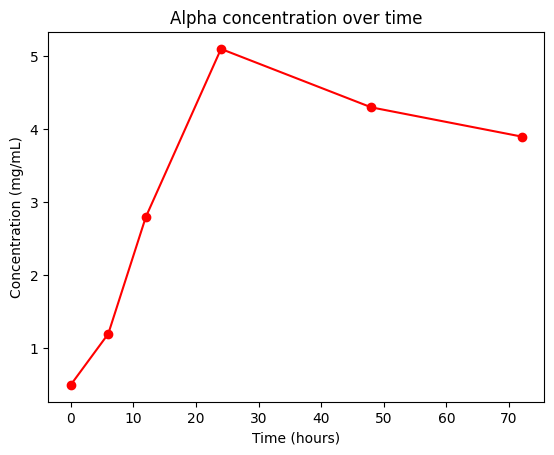

In [49]:
time_hours = [0, 6, 12, 24, 48, 72]
alpha = [0.5, 1.2, 2.8, 5.1, 4.3, 3.9]

# YOUR CODE HERE
plt.plot(time_hours, alpha, marker="o", color = "red")
plt.title("Alpha concentration over time")
plt.xlabel("Time (hours)")
plt.ylabel("Concentration (mg/mL)")
plt.show()

### 3b) Multiple lines on one plot

Now you have concentration data for **all 4 proteins**:

```python
protein_data = {
    "Alpha": [0.5, 1.2, 2.8, 5.1, 4.3, 3.9],
    "Beta":  [1.0, 1.1, 1.3, 1.5, 1.4, 1.6],
    "Gamma": [0.2, 0.8, 2.1, 4.5, 7.2, 9.8],
    "Delta": [3.0, 2.8, 2.5, 2.0, 1.5, 1.0],
}
```

Plot **all 4 proteins** on the same axes using a **for loop** over the dictionary. Each line should have:
- A different color (Matplotlib assigns colors automatically)
- A label matching the protein name
- Circular markers

Add a **legend**, a title `"Protein concentrations over time"`, and axis labels.

In [ ]:
protein_data = {
    "Alpha": [0.5, 1.2, 2.8, 5.1, 4.3, 3.9],
    "Beta":  [1.0, 1.1, 1.3, 1.5, 1.4, 1.6],
    "Gamma": [0.2, 0.8, 2.1, 4.5, 7.2, 9.8],
    "Delta": [3.0, 2.8, 2.5, 2.0, 1.5, 1.0],
}



# YOUR CODE HERE

### 3c) Bar chart — compare proteins at the final time point

Create a **bar chart** that compares the concentration of all 4 proteins at the **last time point** (72 hours).

- The x-axis should show the protein names
- The y-axis should show the concentration
- Use a different color for each bar: `colors = ["steelblue", "coral", "seagreen", "orchid"]`
- Add a title: `"Protein concentration at 72h"`
- Add axis labels

In [ ]:
# YOUR CODE HERE

### 3d) Subplots — one plot per protein

Create a **2×2 grid** of subplots (use `plt.subplots(2, 2, figsize=(10, 8))`).

Each subplot should show the line plot for **one protein**, with:
- The protein name as the subplot title
- The same y-axis limits for all subplots: `ax.set_ylim(0, 11)` — so plots are visually comparable
- X-axis label `"Time (hours)"` and y-axis label `"Conc. (mg/mL)"` on each subplot

Call `plt.tight_layout()` at the end.

**Hint:** `axes = axes.flatten()` turns the 2×2 array of axes into a flat list of 4, so you can loop with `zip(axes, protein_data.items())`.

In [ ]:
# YOUR CODE HERE

---
## Exercise 4 — Expression Matrix Analysis with NumPy

A bioinformatician has a small gene expression matrix: rows are genes, columns are samples. Each value represents how active a gene is in that sample.

**Topics:** NumPy — array creation, indexing, vectorized operations, boolean masking, statistics

In [ ]:
import numpy as np

### 4a) Create the expression matrix

Create a NumPy array `expr` from the data below (4 genes × 5 samples) and print its **shape** and **data type**.

```
         Sample1  Sample2  Sample3  Sample4  Sample5
BRCA1      5.1      3.2      8.0      6.5      7.1
TP53      10.2      9.8     11.0      8.5      9.0
EGFR       2.3      1.8      3.5      2.0      2.9
MYC        7.0      6.5      7.8      8.2      6.0
```

Also create a list `gene_names = ["BRCA1", "TP53", "EGFR", "MYC"]` for reference.

In [ ]:
# YOUR CODE HERE

### 4b) Per-gene statistics

Using NumPy (no loops), compute and print for **each gene** (i.e. each row):
1. The **mean** expression
2. The **standard deviation**

Print results like:
```
BRCA1 — mean: 5.98, std: 1.69
TP53  — mean: 9.70, std: 0.87
...
```

**Hint:** use `axis=1` to compute along columns (i.e. across samples for each gene).

In [ ]:
# YOUR CODE HERE

### 4c) Boolean masking — find highly expressed values

A gene-sample value is considered **highly expressed** if it is above 7.0.

1. Create a boolean mask `high_mask = expr > 7.0`
2. Print the mask
3. Print how many values in the entire matrix are highly expressed (use `.sum()`)
4. Print all the highly expressed values (use the mask to index `expr`)

In [ ]:
# YOUR CODE HERE

### 4d) Normalize the matrix (z-score)

A common preprocessing step is **z-score normalization per gene** (per row):

$$z = \frac{x - \text{mean}}{\text{std}}$$

Compute the z-scored matrix using the means and stds from 4b. Store it in `expr_z` and print it rounded to 2 decimals.

**Hint:** `mean` and `std` from 4b are 1D arrays of shape `(4,)`. To subtract/divide row-wise from a `(4, 5)` array, you need to reshape them to `(4, 1)` using `.reshape(-1, 1)`.

In [ ]:
# YOUR CODE HERE

---
## Exercise 5 — Clinical Trial Dashboard

A research team ran a small clinical trial. They measured a blood marker (CRP level, mg/L) in patients across three treatment groups, and now need to explore and visualize the data.

**Topics:** Pandas (DataFrame, filtering, groupby, NaN handling), Matplotlib (bar chart, scatter plot)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

### 5a) Create the DataFrame

Create a DataFrame `df` from the dictionary below and print it.

```python
data = {
    "patient_id": ["P01", "P02", "P03", "P04", "P05", "P06", "P07", "P08", "P09", "P10", "P11", "P12"],
    "group": ["Drug_A", "Drug_A", "Drug_A", "Drug_A",
              "Drug_B", "Drug_B", "Drug_B", "Drug_B",
              "Placebo", "Placebo", "Placebo", "Placebo"],
    "age": [45, 52, 39, 61, 55, 48, None, 42, 60, 37, 50, 44],
    "crp_before": [12.5, 15.3, 9.8, 18.1, 14.2, 11.0, 16.7, 13.5, 10.9, 14.8, None, 12.2],
    "crp_after":  [7.2, 8.1, 5.5, 10.3, 10.8, 8.5, 12.1, 9.0, 10.5, 13.9, 11.8, 11.5],
}
```

Then print:
1. The shape of the DataFrame
2. How many missing values (`NaN`) are in each column (use `.isna().sum()`)

In [ ]:
# YOUR CODE HERE

### 5b) Handle missing data and add a new column

1. Fill missing `age` values with the **median** age of the dataset (use `.fillna()`)
2. **Drop** rows where `crp_before` is missing (use `.dropna(subset=[...])`)
3. Add a new column `crp_change` = `crp_before` - `crp_after` (positive means improvement)

Print the updated DataFrame.

In [ ]:
# YOUR CODE HERE

### 5c) Group analysis

Using `.groupby("group")`, compute and print the **mean** `crp_change` for each treatment group.

Which group shows the largest average improvement?

In [ ]:
# YOUR CODE HERE

### 5d) Visualization

Create **two plots** side by side (use `plt.subplots(1, 2, figsize=(12, 5))`):

1. **Bar chart** (left): mean `crp_change` per group. Add a title `"Mean CRP Change by Group"` and label the axes.
2. **Scatter plot** (right): `age` on the x-axis vs `crp_change` on the y-axis. Color the points by group (use a different color for each group by looping over groups). Add a title, axis labels, and a legend.

Call `plt.tight_layout()` at the end.

In [ ]:
# YOUR CODE HERE

---

## End of Exam

Please make sure you have **saved this notebook** before submitting. Good luck!